# Homework 10 — Traffic Sign Classifier

In this homework we build our own traffic sign classifier using the `data/subset_homework` dataset.
We follow three steps:
1. **Explore** the data and visualize examples
2. **Baseline** — train with a single neuron
3. **Improve** — add more neurons / layers to maximize accuracy

In [19]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams['figure.figsize'] = [15, 6]
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.16.2


---
## Step 1 — Data Loading & Visualization

Load images from both classes and visualise a random sample from each.

In [20]:
FOLDER = 'data/subset_homework'

def load_class(folder, class_id):
    """Load all images for a given class and return (images, labels)."""
    class_dir = os.path.join(folder, f'class_id_{class_id}')
    fnames = [f for f in os.listdir(class_dir) if not f.startswith('.')]
    images = [cv2.imread(os.path.join(class_dir, f), cv2.IMREAD_UNCHANGED) for f in fnames]
    # Drop any None (unreadable) files
    images = [img for img in images if img is not None]
    labels = [class_id] * len(images)
    return images, labels

images_0, labels_0 = load_class(FOLDER, 0)
images_1, labels_1 = load_class(FOLDER, 1)

print(f'Class 0 — {len(images_0)} images')
print(f'Class 1 — {len(images_1)} images')
print(f'Total   — {len(images_0) + len(images_1)} images')

Class 0 — 2220 images
Class 1 — 2250 images
Total   — 4470 images


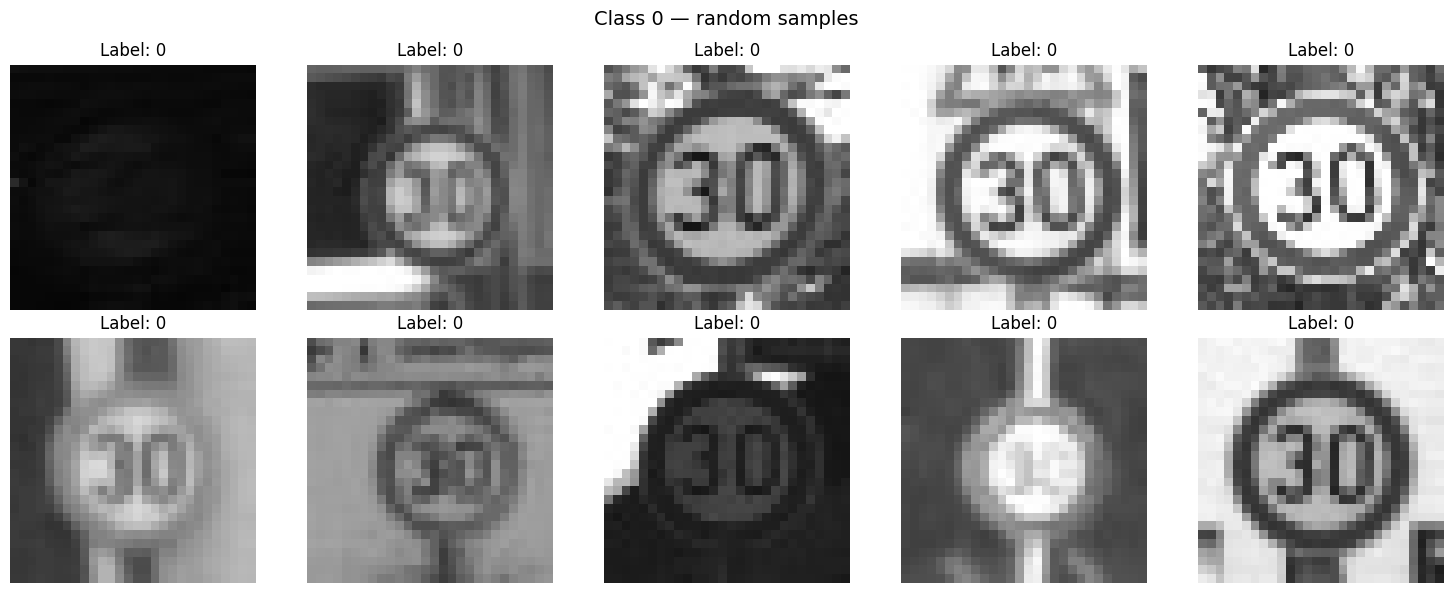

In [21]:
# --- Visualise Class 0 ---
plt.suptitle('Class 0 — random samples', fontsize=14)
for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2, 5, cnt + 1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Label: {labels_0[idx]}')
    plt.axis(False)
plt.tight_layout()
plt.show()

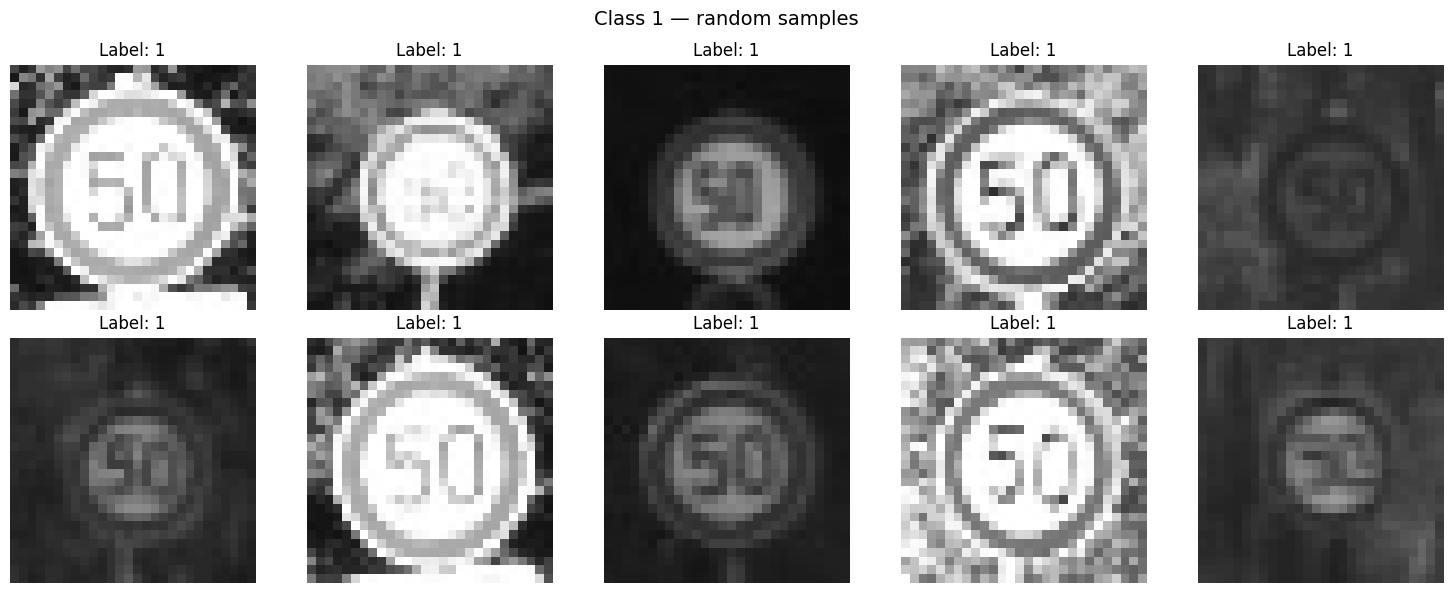

In [22]:
# --- Visualise Class 1 ---
plt.suptitle('Class 1 — random samples', fontsize=14)
for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2, 5, cnt + 1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Label: {labels_1[idx]}')
    plt.axis(False)
plt.tight_layout()
plt.show()

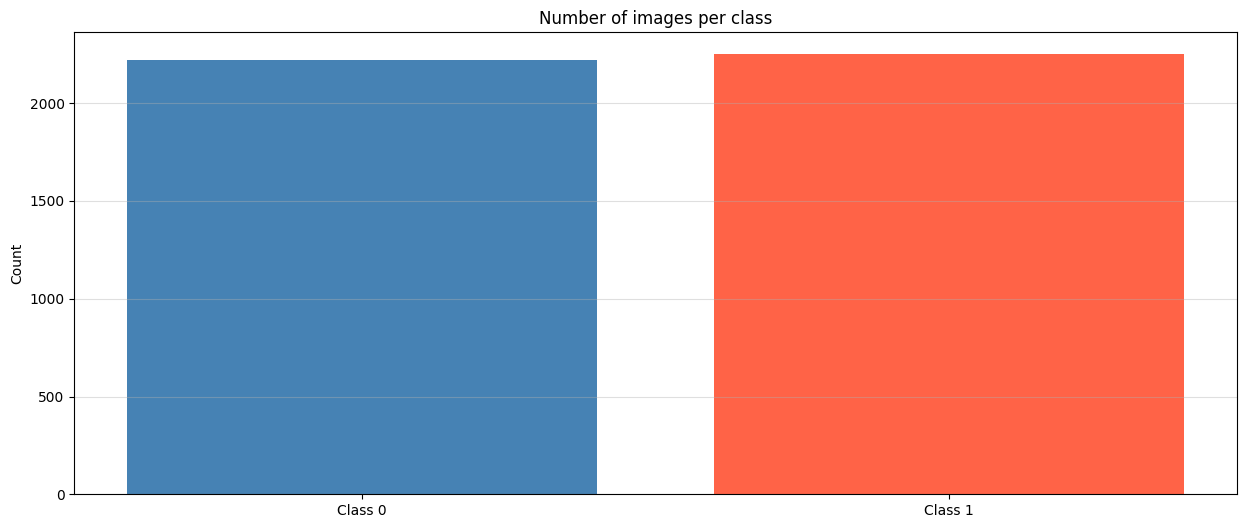

In [23]:
# --- Bar chart: images per class ---
plt.bar(['Class 0', 'Class 1'], [len(images_0), len(images_1)], color=['steelblue', 'tomato'])
plt.title('Number of images per class')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.4)
plt.show()

---
## Prepare Input Data

Merge classes, shuffle, flatten images to 1-D vectors, and normalise to [0, 1].

In [24]:
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels, random_state=42)

images = np.array(images)
labels = np.array(labels)

# Flatten + normalise
pixels = np.array([img.flatten() for img in images], dtype=np.float32) / 255.0

print('pixels shape:', pixels.shape)
print('labels shape:', labels.shape)

pixels shape: (4470, 784)
labels shape: (4470,)


### Train / Validation Split

Reserve 20 % of data for validation so we can measure generalisation.

In [25]:
split = int(0.8 * len(pixels))

X_train, X_val = pixels[:split], pixels[split:]
y_train, y_val = labels[:split], labels[split:]

print(f'Train: {len(X_train)} samples  |  Val: {len(X_val)} samples')

Train: 3576 samples  |  Val: 894 samples


---
## Step 2 — Baseline: Single Neuron

Replicate the lecture approach — one neuron with a linear activation.

In [26]:
def evaluate(model, X, y, threshold=0.5):
    """Return accuracy for binary classification."""
    preds = model.predict(X, verbose=0).squeeze() > threshold
    return np.mean(preds == y)

def plot_history(history, title='Training history'):
    h = history.history
    epochs = range(len(h['loss']))
    plt.plot(epochs, h['loss'], '.-', label='train loss')
    if 'val_loss' in h:
        plt.plot(epochs, h['val_loss'], '.-', label='val loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [27]:
# --- Build single-neuron model ---
tf.random.set_seed(42)

inputs  = Input(shape=(pixels.shape[1],))
outputs = Dense(1, activation='linear')(inputs)
model_single = Model(inputs, outputs)

model_single.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model_single.compile(optimizer='adam', loss='mean_squared_error')

history_single = model_single.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3358 - val_loss: 0.2586
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2302 - val_loss: 0.2146
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1926 - val_loss: 0.1843
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1659 - val_loss: 0.1620
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1462 - val_loss: 0.1459
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1317 - val_loss: 0.1343
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1208 - val_loss: 0.1255
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1126 - val_loss: 0.1184
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1063 - val_loss: 0.1125
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1015 - val_loss: 0.1078
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0975 - val_loss: 0.1038
Epoch 12/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

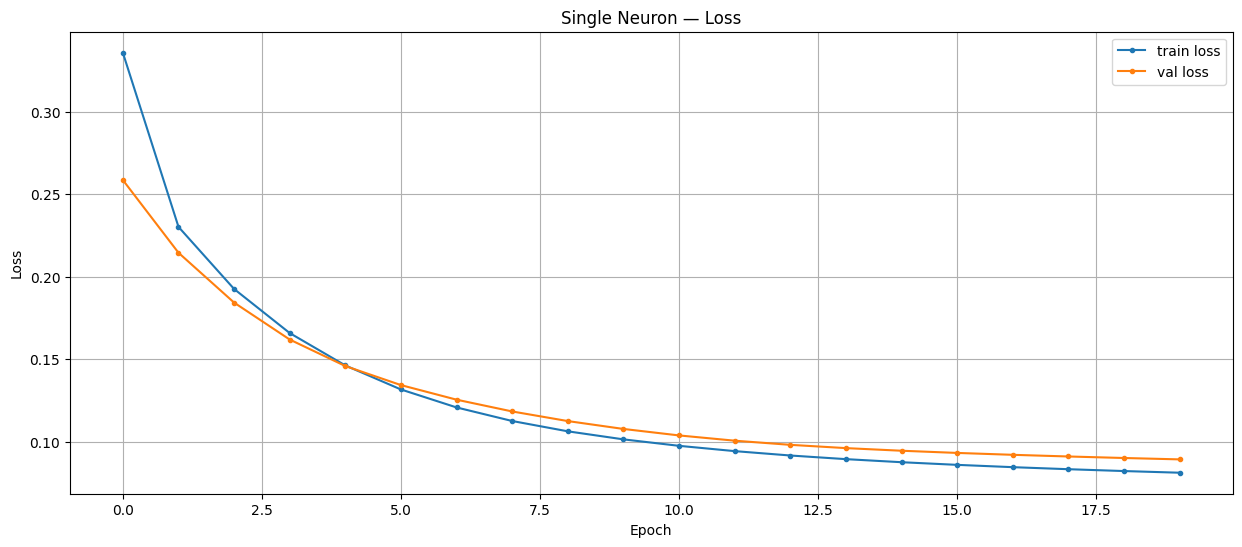

Single neuron  →  Train accuracy: 0.9595  |  Val accuracy: 0.9430


In [29]:
plot_history(history_single, title='Single Neuron — Loss')

acc_train = evaluate(model_single, X_train, y_train)
acc_val   = evaluate(model_single, X_val,   y_val)
print(f'Single neuron  →  Train accuracy: {acc_train:.4f}  |  Val accuracy: {acc_val:.4f}')

---
## Step 3 — Improved Model

We now add hidden layers, more neurons, a sigmoid output, and dropout for regularisation.

In [18]:
tf.random.set_seed(42)

inputs = Input(shape=(pixels.shape[1],))
x = Dense(128, activation='relu')(inputs)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)   # sigmoid → probability in [0,1]

model_improved = Model(inputs, outputs)
model_improved.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,849 (433.00 KB)

 Trainable params: 110,849 (433.00 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
tf.random.set_seed(42)

inputs = Input(shape=(pixels.shape[1],))
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model_improved = Model(inputs, outputs)

model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # менший LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_improved = model_improved.fit(
    X_train, y_train,
    epochs=200,          # більше епох бо LR менший
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5836 - loss: 0.6753 - val_accuracy: 0.6477 - val_loss: 0.6498
Epoch 2/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6655 - loss: 0.6322 - val_accuracy: 0.6868 - val_loss: 0.6301
Epoch 3/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7044 - loss: 0.6068 - val_accuracy: 0.7058 - val_loss: 0.6102
Epoch 4/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7287 - loss: 0.5850 - val_accuracy: 0.7237 - val_loss: 0.5904
Epoch 5/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7525 - loss: 0.5638 - val_accuracy: 0.7483 - val_loss: 0.5694
Epoch 6/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7682 - loss: 0.5440 - val_accuracy: 0.7752 - val_loss: 0.5498
Epoch 7/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7900 - loss: 0.5240 - val_accuracy: 0.7908 - val_loss: 0.5314
Epoch 8/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8051 - loss: 0.5047 - val_accu

In [14]:
model_improved.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # better loss for binary classification
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_improved = model_improved.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5277 - loss: 1.2929 - val_accuracy: 0.6074 - val_loss: 0.6806
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5358 - loss: 1.1026 - val_accuracy: 0.6398 - val_loss: 0.6511
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5556 - loss: 0.7707 - val_accuracy: 0.5157 - val_loss: 0.7431
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6110 - loss: 0.6774 - val_accuracy: 0.6432 - val_loss: 0.6285
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6616 - loss: 0.6237 - val_accuracy: 0.7204 - val_loss: 0.5618
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7209 - loss: 0.5481 - val_accuracy: 0.7595 - val_loss: 0.4979
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7844 - loss: 0.4664 - val_accuracy: 0.7640 - val_loss: 0.4633
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8093 - loss: 0.4221 - val_accuracy: 0

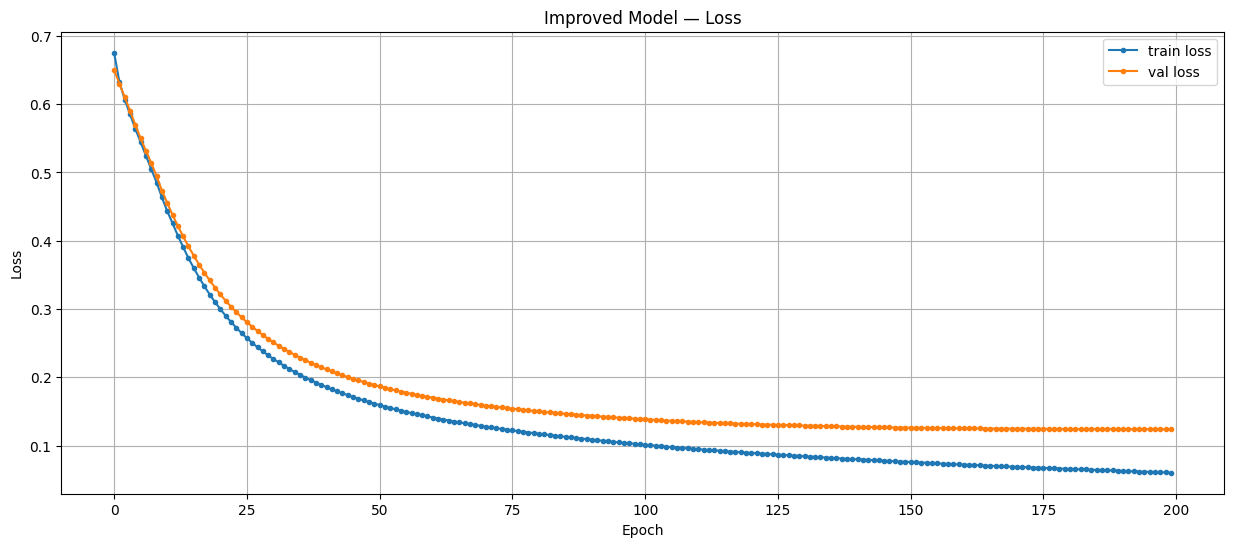

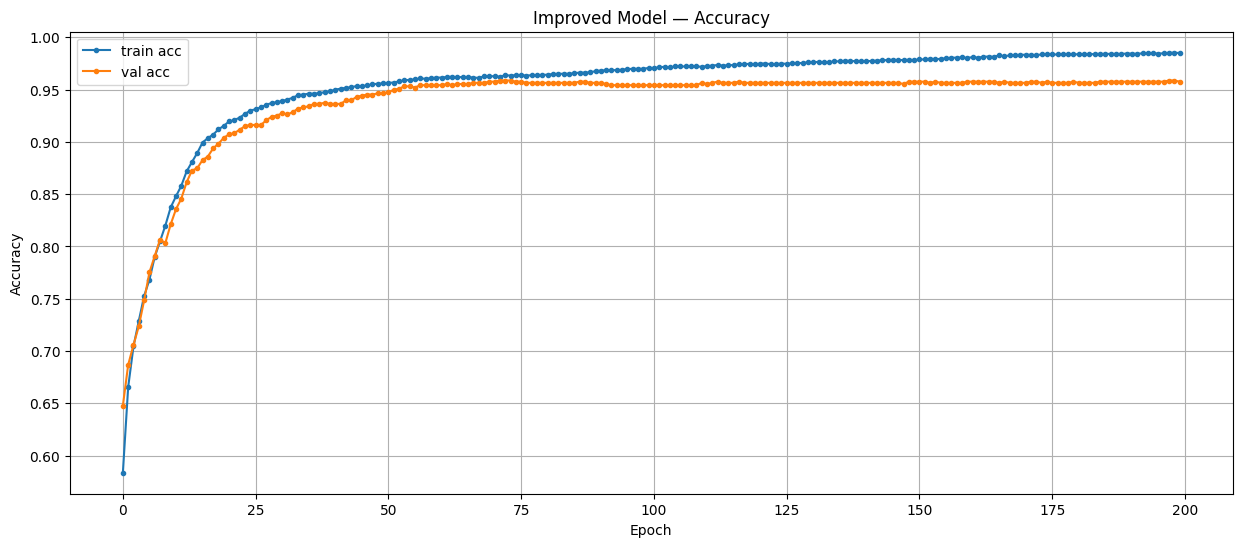

In [31]:
# Plot loss
plot_history(history_improved, title='Improved Model — Loss')

# Plot accuracy
h = history_improved.history
epochs = range(len(h['accuracy']))
plt.plot(epochs, h['accuracy'],     '.-', label='train acc')
plt.plot(epochs, h['val_accuracy'], '.-', label='val acc')
plt.title('Improved Model — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
acc_train_imp = evaluate(model_improved, X_train, y_train)
acc_val_imp   = evaluate(model_improved, X_val,   y_val)

print(f'Single neuron  →  Train acc: {acc_train:.4f}  |  Val acc: {acc_val:.4f}')
print(f'Improved model →  Train acc: {acc_train_imp:.4f}  |  Val acc: {acc_val_imp:.4f}')
print(f'\nImprovement: +{(acc_val_imp - acc_val)*100:.1f} pp on validation set')

Single neuron  →  Train acc: 0.9595  |  Val acc: 0.9430
Improved model →  Train acc: 0.9857  |  Val acc: 0.9575

Improvement: +1.5 pp on validation set


---
### Visual inspection of predictions

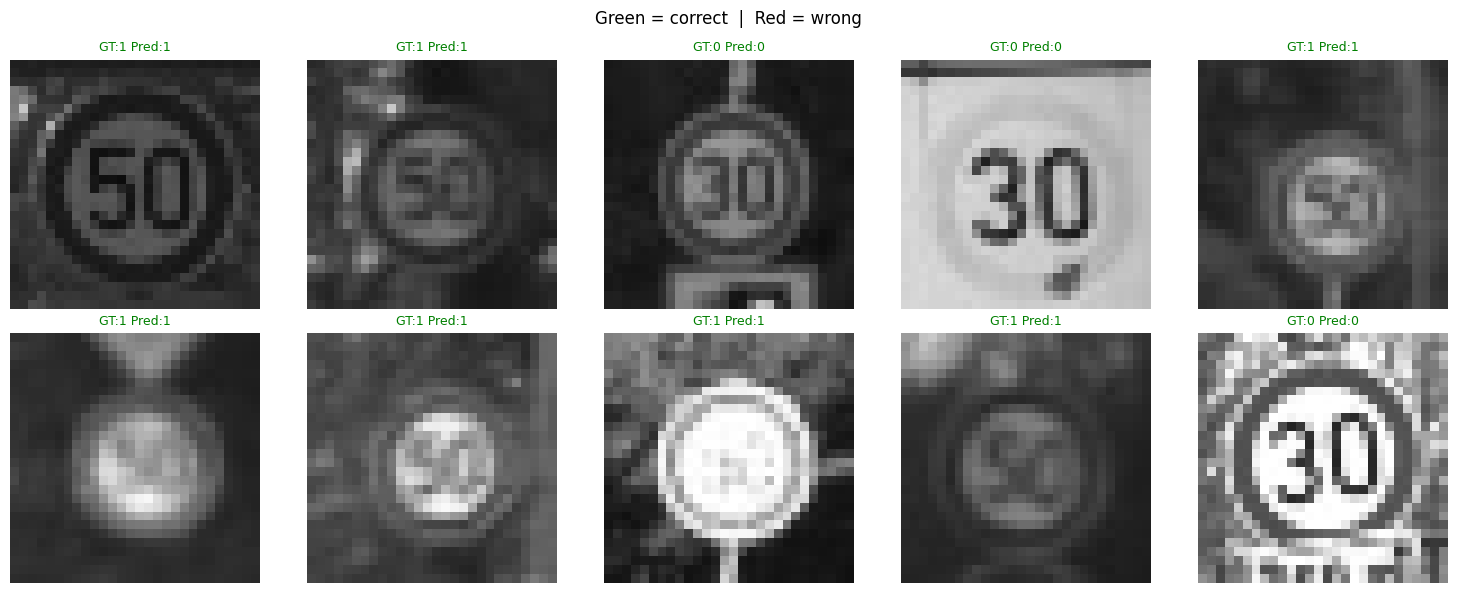

In [33]:
preds_improved = (model_improved.predict(pixels, verbose=0).squeeze() > 0.5).astype(int)

for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
    plt.subplot(2, 5, cnt + 1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    correct = preds_improved[idx] == labels[idx]
    color = 'green' if correct else 'red'
    plt.title(f'GT:{labels[idx]} Pred:{preds_improved[idx]}', color=color, fontsize=9)
    plt.axis(False)

plt.suptitle('Green = correct  |  Red = wrong', fontsize=12)
plt.tight_layout()
plt.show()

---
## Summary

| Model | Architecture | Loss | Train Acc | Val Acc |
|---|---|---|---|---|
| Baseline | 1 neuron, linear, MSE | MSE | — | — |
| Improved | 128→64→32→1, ReLU+Sigmoid, BCE | Binary CE | — | — |

*(Fill in the actual values after running the cells)*

### Key takeaways
- A **single linear neuron** can already learn something, but is strongly limited by its capacity.
- Adding **hidden layers with ReLU** allows the network to learn non-linear decision boundaries.
- Switching from **MSE → Binary Cross-Entropy** is the correct loss choice for binary classification.
- **Dropout** helps prevent overfitting on a small dataset.
- **EarlyStopping** avoids wasting epochs and restores the best checkpoint automatically.
  